## Setup
This notebook requires some packages besides pytorch-lightning.

In [1]:
import os 

os.chdir('../..')

In [27]:
import os
import urllib.request
from types import SimpleNamespace
from urllib.error import HTTPError

import matplotlib
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
import numpy as np
import pytorch_lightning as pl
import seaborn as sns
import tabulate
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision

%matplotlib inline
from IPython.display import HTML, display
from PIL import Image
from torchvision import transforms
from torchvision.datasets import CIFAR10, STL10

matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")  # For export
matplotlib.rcParams["lines.linewidth"] = 2.0
sns.reset_orig()

# PyTorch
# Torchvision

We will use the same `set_seed` function as in the previous tutorials, as well as the path variables `DATASET_PATH` and `CHECKPOINT_PATH`.
Adjust the paths if necessary.

In [61]:
train_dataset.data.shape

(5000, 96, 3, 96)

In [108]:
DATASET = 'STL10' # STL10 or CIFAR10
# DATASET = 'CIFAR10'

if DATASET == 'STL10':
    DATASET_PATH = '/home/leostre/Рабочий стол/SoftStairs-QAT/experiments/SimCLR/data'
    DATASET_CLS = STL10

    
    train_dataset = DATASET_CLS(root=DATASET_PATH, split='train', download=True)
    from numpy import permute_dims
    # transpose_order = [0, 2, 3, 1]
    # train_dataset.data = permute_dims(train_dataset.data, transpose_order)
    # DATA_MEANS = (train_dataset.data / 255.0).mean(axis=(0, 1, 2))
    # DATA_STD = (train_dataset.data / 255.0).std(axis=(0, 1, 2, ))
    test_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(0.5, 0.5)])
    # For training, we add some augmentation. Networks are too powerful and would overfit.
    train_transform = transforms.Compose(
        [
        transforms.RandomHorizontalFlip(),
        transforms.RandomResizedCrop(size=32),
        # transforms.RandomApply([transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1)], p=0.8),
        # transforms.RandomGrayscale(p=0.2),
        # transforms.GaussianBlur(kernel_size=9),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
        
    )
    train_dataset = DATASET_CLS(root=DATASET_PATH, split='train', transform=train_transform, download=False)
    val_dataset = DATASET_CLS(root=DATASET_PATH, split='train', transform=test_transform, download=False)
    # train_dataset.data = permute_dims(train_dataset.data, transpose_order)
    # val_dataset.data = permute_dims(val_dataset.data, transpose_order)
    pl.seed_everything(42)
    train_set, _ = torch.utils.data.random_split(train_dataset, [4000, 1000])
    pl.seed_everything(42)
    _, val_set = torch.utils.data.random_split(val_dataset, [4000, 1000])

    # Loading the test set
    test_set = DATASET_CLS(root=DATASET_PATH,  split='test', transform=test_transform, download=True)
    # test_set.data = permute_dims(test_set.data, transpose_order)

    # We define a set of data loaders that we can use for various purposes later.
    train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=4)
    val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)
    test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)
else: 
    DATASET_PATH = os.environ.get("PATH_DATASETS", "data/")
    DATASET_CLS = CIFAR10
    train_dataset = DATASET_CLS(root=DATASET_PATH, train=True, download=True)
    DATA_MEANS = (train_dataset.data / 255.0).mean(axis=(0, 1, 2))
    DATA_STD = (train_dataset.data / 255.0).std(axis=(0, 1, 2))
    test_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(DATA_MEANS, DATA_STD)])
    # For training, we add some augmentation. Networks are too powerful and would overfit.
    train_transform = transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0), ratio=(0.9, 1.1)),
            transforms.ToTensor(),
            transforms.Normalize(DATA_MEANS, DATA_STD),
        ]
    )
    # Loading the training dataset. We need to split it into a training and validation part
    # We need to do a little trick because the validation set should not use the augmentation.
    train_dataset = CIFAR10(root=DATASET_PATH, train=True, transform=train_transform, download=False)
    val_dataset = CIFAR10(root=DATASET_PATH, train=True, transform=test_transform, download=False)
    pl.seed_everything(42)
    train_set, _ = torch.utils.data.random_split(train_dataset, [45000, 5000])
    pl.seed_everything(42)
    _, val_set = torch.utils.data.random_split(val_dataset, [45000, 5000])

    # Loading the test set
    test_set = CIFAR10(root=DATASET_PATH, train=False, transform=test_transform, download=True)

    # We define a set of data loaders that we can use for various purposes later.
    train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=4)
    val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)
    test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)

Seed set to 42
Seed set to 42


In [109]:
# Path to the folder where the datasets are/should be downloaded (e.g. CIFAR10)

# Path to the folder where the pretrained models are saved
CHECKPOINT_PATH = os.environ.get("PATH_CHECKPOINT", "saved_models/ConvNets")

# Function for setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

Seed set to 42


We also have pretrained models and Tensorboards (more on this later) for this tutorial, and download them below.

In [110]:
# Github URL where saved models are stored for this tutorial
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial5/"
# Files to download
pretrained_files = [
    "GoogleNet.ckpt",
    "ResNet.ckpt",
    "ResNetPreAct.ckpt",
    "DenseNet.ckpt",
    "tensorboards/GoogleNet/events.out.tfevents.googlenet",
    "tensorboards/ResNet/events.out.tfevents.resnet",
    "tensorboards/ResNetPreAct/events.out.tfevents.resnetpreact",
    "tensorboards/DenseNet/events.out.tfevents.densenet",
]
# Create checkpoint path if it doesn't exist yet
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# For each file, check whether it already exists. If not, try downloading it.
for file_name in pretrained_files:
    file_path = os.path.join(CHECKPOINT_PATH, file_name)
    if "/" in file_name:
        os.makedirs(file_path.rsplit("/", 1)[0], exist_ok=True)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print(
                "Something went wrong. Please try to download the file from the GDrive folder, or contact the author with the full output including the following error:\n",
                e,
            )

Throughout this tutorial, we will train and evaluate the models on the CIFAR10 dataset.
This allows you to compare the results obtained here with the model you have implemented in the first assignment.
As we have learned from the previous tutorial about initialization, it is important to have the data preprocessed with a zero mean.
Therefore, as a first step, we will calculate the mean and standard deviation of the CIFAR dataset:

In [111]:

print("Data mean", DATA_MEANS)
print("Data std", DATA_STD)

Data mean [0.44671062 0.43980984 0.40664645]
Data std [0.26034098 0.25657727 0.27126738]


We will use this information to define a `transforms.Normalize` module which will normalize our data accordingly.
Additionally, we will use data augmentation during training.
This reduces the risk of overfitting and helps CNNs to generalize better.
Specifically, we will apply two random augmentations.

First, we will flip each image horizontally by a chance of 50% (`transforms.RandomHorizontalFlip`).
The object class usually does not change when flipping an image, and we don't expect any image information to be dependent on the horizontal orientation.
This would be however different if we would try to detect digits or letters in an image, as those have a certain orientation.

The second augmentation we use is called `transforms.RandomResizedCrop`.
This transformation scales the image in a small range, while eventually changing the aspect ratio, and crops it afterward in the previous size.
Therefore, the actual pixel values change while the content or overall semantics of the image stays the same.

We will randomly split the training dataset into a training and a validation set.
The validation set will be used for determining early stopping.
After finishing the training, we test the models on the CIFAR test set.

To verify that our normalization works, we can print out the mean and standard deviation of the single batch.
The mean should be close to 0 and the standard deviation close to 1 for each channel:

In [112]:
imgs, _ = next(iter(train_loader))
print("Batch mean", imgs.mean(dim=[0, 2, 3]))
print("Batch std", imgs.std(dim=[0, 2, 3]))

Batch mean tensor([-0.0533, -0.0862, -0.1496])
Batch std tensor([0.4852, 0.4808, 0.5085])


Finally, let's visualize a few images from the training set, and how they look like after random data augmentation:

In [113]:
NUM_IMAGES = 8
images = [train_dataset[idx][0] for idx in range(NUM_IMAGES)]
orig_images = [Image.fromarray(train_dataset.data[idx]) for idx in range(NUM_IMAGES)]
orig_images = [test_transform(img) for img in orig_images]

img_grid = torchvision.utils.make_grid(torch.stack(images + orig_images, dim=0), nrow=4, normalize=True, pad_value=0.5)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(8, 8))
plt.title(f"Augmentation examples on {DATASET}")
plt.imshow(img_grid)
plt.axis("off")
plt.show()
plt.close()

TypeError: Cannot handle this data type: (1, 1, 96), |u1

## PyTorch Lightning

In this notebook and in many following ones, we will make use of the library [PyTorch Lightning](https://www.lightning.ai/docs/pytorch/stable).
PyTorch Lightning is a framework that simplifies your code needed to train, evaluate, and test a model in PyTorch.
It also handles logging into [TensorBoard](https://pytorch.org/tutorials/intermediate/tensorboard_tutorial.html), a visualization toolkit for ML experiments, and saving model checkpoints automatically with minimal code overhead from our side.
This is extremely helpful for us as we want to focus on implementing different model architectures and spend little time on other code overhead.
Note that at the time of writing/teaching, the framework has been released in version 1.3.
Future versions might have a slightly changed interface and thus might not work perfectly with the code (we will try to keep it up-to-date as much as possible).

Now, we will take the first step in PyTorch Lightning, and continue to explore the framework in our other tutorials.
PyTorch Lightning comes with a lot of useful functions, such as one for setting the seed as we have seen before:

In [114]:
# Setting the seed
pl.seed_everything(42)

Seed set to 42


42

Thus, in the future, we don't have to define our own `set_seed` function anymore.

In PyTorch Lightning, we define `pl.LightningModule`'s (inheriting from `Module`) that organize our code into 5 main sections:

1. Initialization (`__init__`), where we create all necessary parameters/models
2. Optimizers (`configure_optimizers`) where we create the optimizers, learning rate scheduler, etc.
3.
Training loop (`training_step`) where we only have to define the loss calculation for a single batch (the loop of optimizer.zero_grad(), loss.backward() and optimizer.step(), as well as any logging/saving operation, is done in the background)
4.
Validation loop (`validation_step`) where similarly to the training, we only have to define what should happen per step
5. Test loop (`test_step`) which is the same as validation, only on a test set.

Therefore, we don't abstract the PyTorch code, but rather organize it and define some default operations that are commonly used.
If you need to change something else in your training/validation/test loop, there are many possible functions you can overwrite (see the [docs](https://lightning.ai/docs/pytorch/stable/common/lightning_module.html) for details).

Now we can look at an example of how a Lightning Module for training a CNN looks like:

In [115]:
model_dict = {}


def create_model(model_name, model_hparams):
    if model_name in model_dict:
        return model_dict[model_name](**model_hparams)
    else:
        assert False, f'Unknown model name "{model_name}". Available models are: {str(model_dict.keys())}'

### Activation of SSQ

In [116]:

from functools import partial
from softstairs_qat import SoftStairsQuantizer, QuantizationConfig

def get_qconfig(strategy, t_start, steps, n_bits, naive, normalized=False):
    return QuantizationConfig(
        n_bits=n_bits,
        normalized=normalized,
        t_scheduler_strategy=strategy,
        t_start=t_start,
        t_end=1e-4,
        n_steps=steps,
        naive=naive
    )


In [117]:
class SSQStep(pl.Callback):
    def on_train_epoch_end(self, trainer, pl_module):
        if hasattr(pl_module, 'quantizer'):
            pl_module.quantizer.step()
        
    
    def on_train_epoch_start(self, trainer, pl_module):
        if hasattr(pl_module, 'quantizer'):
            t_value = pl_module.quantizer.t
            trainer.logger.log_metrics({"quantizer_t": t_value}, step=trainer.current_epoch)

In [118]:
class CIFARModule(pl.LightningModule):
    def __init__(self, model, model_hparams, optimizer_name, optimizer_hparams, torch_qat=False, quantization_hparams={}):
        """CIFARModule.

        Args:
            model_name: Name of the model/CNN to run. Used for creating the model (see function below)
            model_hparams: Hyperparameters for the model, as dictionary.
            optimizer_name: Name of the optimizer to use. Currently supported: Adam, SGD
            optimizer_hparams: Hyperparameters for the optimizer, as dictionary. This includes learning rate, weight decay, etc.

        """
        super().__init__()
        # Exports the hyperparameters to a YAML file, and create "self.hparams" namespace
        self.save_hyperparameters()

        # Create model
        self.model = create_model(model, model_hparams) if isinstance(model, str) else model
        self.torch_qat = torch_qat

        self._prepare_quantization()
        # Create loss module
        self.loss_module = nn.CrossEntropyLoss()
        # Example input for visualizing the graph in Tensorboard
        self.example_input_array = torch.zeros((1, 3, 32, 32), dtype=torch.float32)

    def _prepare_quantization(self):
        if self.torch_qat:
            from torchao.quantization import quantize_, Int8WeightOnlyConfig, Int4WeightOnlyConfig
            qconfig = Int4WeightOnlyConfig(group_size=32) if self.hparams.quantization_hparams['n_bits'] == 4 else Int8WeightOnlyConfig(group_size=32)
            quantize_(self.model, qconfig)
            
        else:
            excluded_modules = {
                    n for n, p in self.model.named_modules()
                    if "bn" in n
            }
            
            qconfig = get_qconfig(**self.hparams.quantization_hparams,)
            self.quantizer = SoftStairsQuantizer(
                            self.model,
                            qconfig,
                            excluded_modules=excluded_modules,
                )

    def forward(self, imgs):
        # Forward function that is run when visualizing the graph
        return self.model(imgs)

    def configure_optimizers(self):
        # We will support Adam or SGD as optimizers.
        if self.hparams.optimizer_name == "Adam":
            # AdamW is Adam with a correct implementation of weight decay (see here
            # for details: https://arxiv.org/abs/1711.05101)
            optimizer = optim.AdamW(self.parameters(), **self.hparams.optimizer_hparams)
        elif self.hparams.optimizer_name == "SGD":
            optimizer = optim.SGD(self.parameters(), **self.hparams.optimizer_hparams)
        else:
            assert False, f'Unknown optimizer: "{self.hparams.optimizer_name}"'

        # We will reduce the learning rate by 0.1 after 100 and 150 epochs
        scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 150], gamma=0.1)
        return [optimizer], [scheduler]

    def training_step(self, batch, batch_idx):
        # "batch" is the output of the training data loader.
        imgs, labels = batch
        preds = self.model(imgs)
        loss = self.loss_module(preds, labels)
        acc = (preds.argmax(dim=-1) == labels).float().mean()

        # Logs the accuracy per epoch to tensorboard (weighted average over batches)
        self.log("train_acc", acc, on_step=False, on_epoch=True)
        self.log("train_loss", loss)
        return loss  # Return tensor to call ".backward" on

    def validation_step(self, batch, batch_idx):
        imgs, labels = batch
        preds = self.model(imgs)
        acc = (labels == preds.argmax(dim=-1)).float().mean()
        loss = self.loss_module(preds, labels)
        # By default logs it per epoch (weighted average over batches)
        self.log("val_acc", acc)
        self.log("val_loss", loss)

    def test_step(self, batch, batch_idx):
        imgs, labels = batch
        preds = self.model(imgs).argmax(dim=-1)
        acc = (labels == preds).float().mean()
        # By default logs it per epoch (weighted average over batches), and returns it afterwards
        self.log("test_acc", acc)

In [119]:
# Callbacks
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint  # noqa: E402/

In [120]:
from pytorch_lightning.loggers import CSVLogger 

def train_model(model_name, save_name=None, epochs=100, torch_qat=False, quantization_hparams={}, retrain=False, **kwargs):
    """Train model.

    Args:
        model_name: Name of the model you want to run. Is used to look up the class in "model_dict"
        save_name (optional): If specified, this name will be used for creating the checkpoint and logging directory.

    """
    if save_name is None:
        save_name = model_name


    logger = CSVLogger(
        save_dir="experiments/CV/logs",
        name=save_name,
    )

    # Create a PyTorch Lightning trainer with the generation callback
    trainer = pl.Trainer(
        default_root_dir=os.path.join(CHECKPOINT_PATH, save_name),  # Where to save models
        # We run on a single GPU (if possible)
        accelerator="auto",
        devices=1,
        # How many epochs to train for if no patience is set
        max_epochs=epochs,
        callbacks=[
            SSQStep(),
            # ModelCheckpoint(
            #     save_weights_only=True, mode="max", monitor="val_acc"
            # ),  # Save the best checkpoint based on the maximum val_acc recorded. Saves only weights and not optimizer
            LearningRateMonitor("epoch"),
        ],  # Log learning rate every epoch
        logger=logger,

    )  # In case your notebook crashes due to the progress bar, consider increasing the refresh rate
    # trainer.logger._log_graph = True  # If True, we plot the computation graph in tensorboard
    trainer.logger._default_hp_metric = None  # Optional logging argument that we don't need

    # Check whether pretrained model exists. If yes, load it and skip training
    pretrained_filename = os.path.join(CHECKPOINT_PATH, save_name + ".ckpt")
    if not retrain and os.path.isfile(pretrained_filename):
        print(f"Found pretrained model at {pretrained_filename}, loading...")
        # Automatically loads the model with the saved hyperparameters
        model = CIFARModule.load_from_checkpoint(pretrained_filename, quantization_hparams=quantization_hparams | {'steps': epochs})
    else:
        pl.seed_everything(42)  # To be reproducible
        model = CIFARModule(model=model_name, quantization_hparams=quantization_hparams  | {'steps': epochs}, torch_qat=torch_qat,  **kwargs)
        trainer.fit(model, train_loader, val_loader)
        model = CIFARModule.load_from_checkpoint(
            trainer.checkpoint_callback.best_model_path
        )  # Load best checkpoint after training

    # Test best model on validation and test set
    val_result = trainer.test(model, dataloaders=val_loader, verbose=False)
    test_result = trainer.test(model, dataloaders=test_loader, verbose=False)
    result = {"test": test_result[0]["test_acc"], "val": val_result[0]["test_acc"]}

    return model, result

Finally, we can focus on the Convolutional Neural Networks we want to
implement today: GoogleNet, ResNet, and DenseNet.

In [121]:
from experiments.CV.models import *

## Inception

In [ ]:
MODEL_NAME = 'GoogleNet'

In [ ]:
googlenet_model, googlenet_results = train_model(
    model_name=MODEL_NAME,
    save_name=f'{MODEL_NAME}_{DATASET}',
    model_hparams={"num_classes": 10, "act_fn_name": "relu"},
    optimizer_name="Adam",
    optimizer_hparams={"lr": 1e-3, "weight_decay": 0.},
    quantization_hparams=dict(strategy='linear',
        t_start=0.9,
        n_bits=8,
        naive=False,
        normalized=True),
    torch_qat=True,
    retrain=True,
    epochs=30
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42
/home/leostre/Рабочий стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/torchao/quantization/quant_api.py:936: UserWarning: Config Deprecation: version 1 of Int8WeightOnlyConfig is deprecated and will no longer be supported in a future release, please use version 2, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/leostre/Рабочий стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/leostre/Рабочий стол/SoftSta

┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name        ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃       In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ model       │ GoogleNet        │  260 K │ train │ 159 M │ [1, 3, 32, 32] │   [1, 10] │
│ 1 │ loss_module │ CrossEntropyLoss │      0 │ train │     0 │              ? │         ? │
└───┴─────────────┴──────────────────┴────────┴───────┴───────┴────────────────┴───────────┘

Trainable params: 259 K                                                                                            
Non-trainable params: 1.3 K                                                                                        
Total params: 260 K                                                                                                
Total estimated model params size (MB): 1.043                                                                      
Modules in train mode: 205                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 159 M

Output()

/home/leostre/Рабочий 
стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/home/leostre/Рабочий 
стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:321: The number of 
training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for 
log_every_n_steps if you want to see logs for the training epoch.


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/leostre/Рабочий стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


We will compare the results later in the notebooks, but we can already print them here for a first glance:

In [168]:
print("GoogleNet Results", googlenet_results)

GoogleNet Results {'test': 0.6263999938964844, 'val': 0.6200000047683716}


In [31]:
from pathlib import Path 
import pandas as pd 


def read_results(name, scale='step'):
    path = Path(f'experiments/CV/logs/{name}')
    latest_version = sorted(os.listdir(path), key=lambda x: float(x.split('_')[-1]))[-1]
    file = path / latest_version / 'metrics.csv' 
    df = pd.read_csv(file)
    
    
    test_epoch = df['epoch'].iloc[-1]
    is_test = df.epoch >= test_epoch

    df.bfill(inplace=True)
    test_mtr = 0.
    if 'test_acc' in df.columns:
        test_mtr = df.test_acc.iloc[-1]
        df.drop(['test_acc'], axis=1, inplace=True)
    df = df.loc[~is_test, :]
    df.ffill(inplace=True)
    # df.dropna(inplace=True)
    df = df.groupby(scale).last().reset_index()
    return df, test_mtr

dynamics, test_mtr = read_results('GoogleNet_normalized')

array([[<Axes: title={'center': 'losses'}, xlabel='epoch', ylabel='train_loss'>,
        <Axes: title={'center': 'metrics'}, xlabel='epoch', ylabel='train_acc'>],
       [<Axes: >, <Axes: >]], dtype=object)

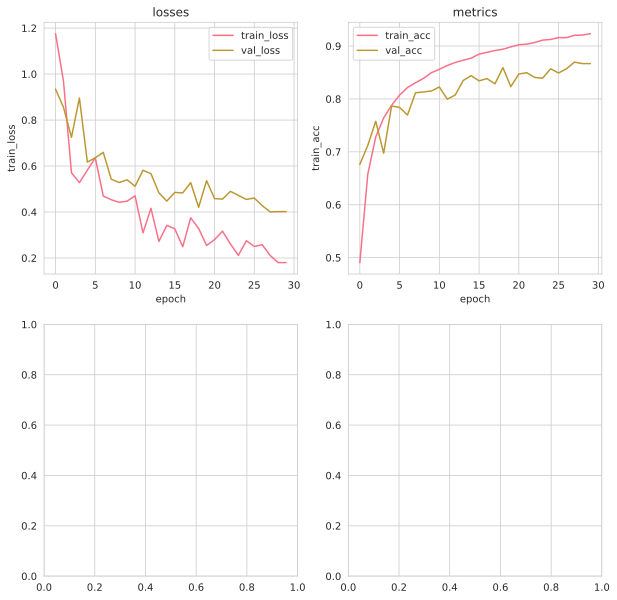

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# Set Seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")


def plot_dynamics(name, scale='step', metric='acc', axes=None, suffix=''):
    dynamics, final_results = read_results(name, scale)
    
    if axes is None:
        fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    # losses
    for c in [c for c in dynamics.columns if c.endswith('loss')]:
        sns.lineplot(dynamics, x=scale, y=c, ax=axes[0][0], label=c + suffix)
    axes[0][0].legend()
    axes[0][0].set_title('losses') 

    # mtr

    for c in [c for c in dynamics.columns if metric in c]:
        sns.lineplot(dynamics, x=scale, y=c, ax=axes[0][1], label=c + suffix)
    axes[0][1].legend()
    axes[0][1].set_title('metrics') 

    if not 'quantizer_t' in dynamics:
        return axes

    # t schedule 
    
    ax = axes[1][0] 
    sns.lineplot(dynamics, x=scale, y='quantizer_t', ax=ax)
    ax.set_title(f't_schedule ')

    # metric vs. t_schedule 

    ax = axes[1][1]
    for c in [c for c in dynamics.columns if metric in c]:
        sns.scatterplot(dynamics, x='quantizer_t', y=c, ax=ax, label=c)
    # sns.scatterplot(dynamics, x='quantizer_t', y=f'train_{metric}', ax=ax)
    ax.set_title(f'{metric} vs. t_schedule ')
    return axes 


plot_dynamics('GoogleNet_normalized', 'epoch')


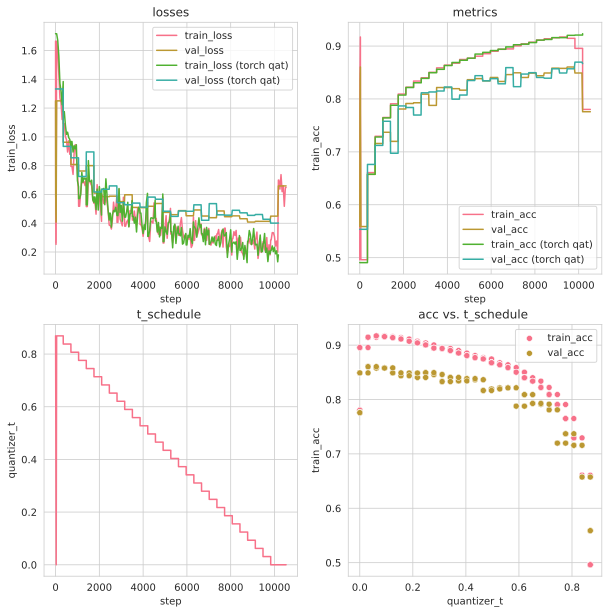

In [36]:
def plot_comparison(exp, baseline, scale, metric):
    axes = plot_dynamics(exp, scale, metric)
    axes = plot_dynamics(baseline, scale, metric, axes, ' (torch qat)')

plot_comparison('GoogleNet', 'GoogleNet_normalized', 'step', 'acc')
    

## ResNet

In [230]:
resnet_model, resnet_results = train_model(
    model_name="ResNet",
    model_hparams={"num_classes": 10, "c_hidden": [16, 32, 64], "num_blocks": [3, 3, 3], "act_fn_name": "relu"},
    optimizer_name="Adam",
    optimizer_hparams={"lr": 1e-3, "weight_decay": 0.},
    quantization_hparams=dict(strategy='linear',
        t_start=0.9,
        n_bits=4,
        naive=False),
    retrain=True,
    epochs=30
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name        ┃ Type             ┃ Params ┃ Mode  ┃  FLOPs ┃       In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ model       │ ResNet           │  272 K │ train │ 81.6 M │ [1, 3, 32, 32] │   [1, 10] │
│ 1 │ loss_module │ CrossEntropyLoss │      0 │ train │      0 │              ? │         ? │
└───┴─────────────┴──────────────────┴────────┴───────┴────────┴────────────────┴───────────┘

Trainable params: 272 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 272 K                                                                                                
Total estimated model params size (MB): 1.090                                                                      
Modules in train mode: 85                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 81.6 M

Output()

/home/leostre/Рабочий 
стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

`Trainer.fit` stopped: `max_epochs=30` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

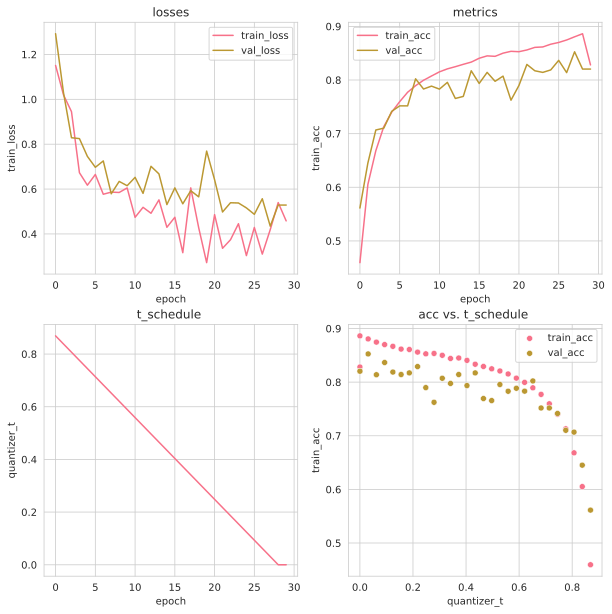

In [232]:
plot_dynamics('ResNet', scale='epoch', metric='acc')

Let's also train the pre-activation ResNet as comparison:

In [234]:
resnetpreact_model, resnetpreact_results = train_model(
    model_name="ResNet",
    model_hparams={
        "num_classes": 10,
        "c_hidden": [16, 32, 64],
        "num_blocks": [3, 3, 3],
        "act_fn_name": "relu",
        "block_name": "PreActResNetBlock",
    },
    optimizer_name="Adam",
    optimizer_hparams={"lr": 1e-3, "weight_decay": 0.},
    quantization_hparams=dict(strategy='linear',
        t_start=0.9,
        n_bits=4,
        naive=False),
    retrain=True,
    epochs=30,
    save_name="ResNetPreAct",
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name        ┃ Type             ┃ Params ┃ Mode  ┃  FLOPs ┃       In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ model       │ ResNet           │  272 K │ train │ 81.6 M │ [1, 3, 32, 32] │   [1, 10] │
│ 1 │ loss_module │ CrossEntropyLoss │      0 │ train │      0 │              ? │         ? │
└───┴─────────────┴──────────────────┴────────┴───────┴────────┴────────────────┴───────────┘

Trainable params: 272 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 272 K                                                                                                
Total estimated model params size (MB): 1.089                                                                      
Modules in train mode: 89                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 81.6 M

Output()

...

`Trainer.fit` stopped: `max_epochs=30` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [ ]:
try:
    train_model(
    model_name="ResNet",
    model_hparams={
        "num_classes": 10,
        "c_hidden": [16, 32, 64],
        "num_blocks": [3, 3, 3],
        "act_fn_name": "relu",
        "block_name": "PreActResNetBlock",
    },
    optimizer_name="Adam",
    optimizer_hparams={"lr": 1e-3, "weight_decay": 0.},
    quantization_hparams=dict(strategy='linear',
        t_start=0.9,
        n_bits=8,
        naive=False),
    retrain=True,
    torch_qat=True,
    epochs=30,
    save_name="ResNetPreActTQAT",
    )
except RuntimeError:
    pass

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42
/home/leostre/Рабочий стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/torchao/quantization/quant_api.py:936: UserWarning: Config Deprecation: version 1 of Int8WeightOnlyConfig is deprecated and will no longer be supported in a future release, please use version 2, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/leostre/Рабочий стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/leostre/Рабочий стол/SoftSta

┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name        ┃ Type             ┃ Params ┃ Mode  ┃  FLOPs ┃       In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ model       │ ResNet           │  272 K │ train │ 81.6 M │ [1, 3, 32, 32] │   [1, 10] │
│ 1 │ loss_module │ CrossEntropyLoss │      0 │ train │      0 │              ? │         ? │
└───┴─────────────┴──────────────────┴────────┴───────┴────────┴────────────────┴───────────┘

Trainable params: 271 K                                                                                            
Non-trainable params: 640                                                                                          
Total params: 272 K                                                                                                
Total estimated model params size (MB): 1.089                                                                      
Modules in train mode: 89                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 81.6 M

Output()

/home/leostre/Рабочий 
стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

`Trainer.fit` stopped: `max_epochs=30` reached.


RuntimeError: Callable map_location not supported with _rebuild_wrapper_subclass or _rebuild_device_tensor_from_numpy

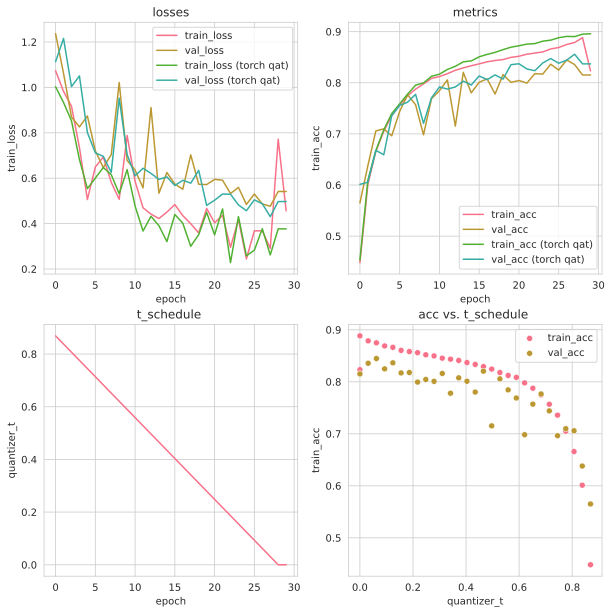

In [42]:
plot_comparison('ResNetPreAct', 'ResNetPreActTQAT', scale='epoch', metric='acc')

## DenseNet

In [17]:
model_dict["DenseNet"] = DenseNet

In [19]:
torch.cuda.empty_cache()

In [18]:
train_model(
    model_name="DenseNet",
    model_hparams={
        "num_classes": 10,
        "num_layers": [16, 16, 16, 16],
        "bn_size": 2,
        "growth_rate": 16,
        "act_fn_name": "relu",
    },
    optimizer_name="Adam",
    optimizer_hparams={"lr": 1e-3, "weight_decay": 0.},
    quantization_hparams=dict(strategy='linear',
        t_start=0.9,
        n_bits=4,
        naive=False),
    retrain=True,
    epochs=30,
);

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 5080') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name        ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃       In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ model       │ DenseNet         │  1.1 M │ train │ 596 M │ [1, 3, 32, 32] │   [1, 10] │
│ 1 │ loss_module │ CrossEntropyLoss │      0 │ train │     0 │              ? │         ? │
└───┴─────────────┴──────────────────┴────────┴───────┴───────┴────────────────┴───────────┘

Trainable params: 1.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 M                                                                                                
Total estimated model params size (MB): 4.493                                                                      
Modules in train mode: 549                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 596 M

Output()

/home/leostre/Рабочий 
стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

`Trainer.fit` stopped: `max_epochs=30` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [19]:
try:
    train_model(
    model_name="DenseNet",
    model_hparams={
        "num_classes": 10,
        "num_layers": [16, 16, 16, 16],
        "bn_size": 2,
        "growth_rate": 16,
        "act_fn_name": "relu",
    },
    optimizer_name="Adam",
    optimizer_hparams={"lr": 1e-3, "weight_decay": 0.},
    quantization_hparams=dict(strategy='linear',
        t_start=0.9,
        n_bits=8,
        naive=False),
    retrain=True,
    epochs=30,
    torch_qat=True
    );
except RuntimeError: pass 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42
/home/leostre/Рабочий стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/torchao/quantization/quant_api.py:936: UserWarning: Config Deprecation: version 1 of Int8WeightOnlyConfig is deprecated and will no longer be supported in a future release, please use version 2, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/leostre/Рабочий стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(


AssertionError: Expecting input size at 1 dimension: 484 to be divisible by block_size at 1 dimension: 32

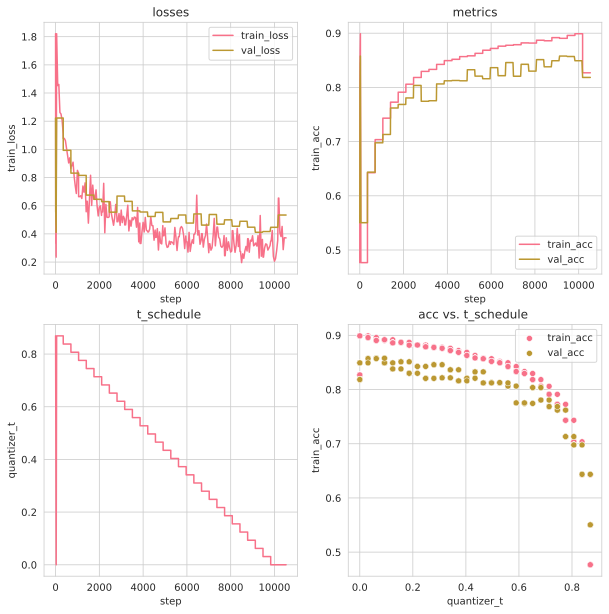

In [239]:
plot_dynamics("DenseNet", 'step')

In [20]:
stl10 = torchvision.datasets.STL10('/home/leostre/Рабочий стол/SoftStairs-QAT/experiments/SimCLR/data')

In [21]:
stl10

Dataset STL10
    Number of datapoints: 5000
    Root location: /home/leostre/Рабочий стол/SoftStairs-QAT/experiments/SimCLR/data
    Split: train

In [25]:
stl10.data.shape

(5000, 3, 96, 96)